In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline
uploaded = files.upload()
default_knn_filename = next(iter(uploaded))
default_knn = pd.read_csv(io.StringIO(uploaded[default_knn_filename].decode('utf-8')))
display(default_knn.head())

Saving defaul_knn.csv to defaul_knn (2).csv


,defaulter,student,balance,income
0,No,Yes,817.1804,12106.14
1,Yes,Yes,1486.9980,17854.40
2,Yes,Yes,1102.4350,17391.78
3,Yes,Yes,1233.4460,12586.48
4,Yes,Yes,1276.6850,19282.44


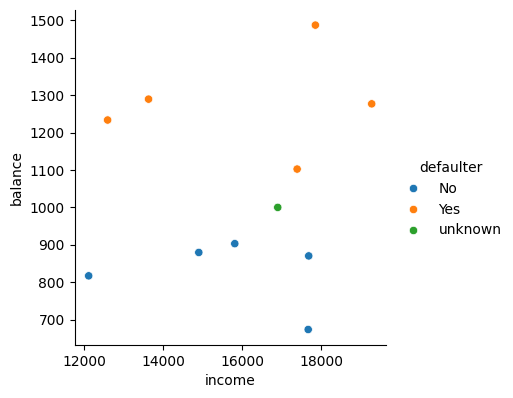

In [ ]:
import seaborn as sns
sns.pairplot(default_knn,hue="defaulter",
             x_vars="income",y_vars="balance",height=4)


In [ ]:
x1 = default_knn.loc[0,["balance","income"]]
x2 = default_knn.loc[1,["balance","income"]]
np.linalg.norm(x1-x2)

np.float64(5787.1537602581275)

In [ ]:
t1 = np.array([26,1000])
t2 = np.array([66,1000])
t3 = np.array([36,10000])
dist_t3_t1 = np.linalg.norm(t3-t1)
dist_t2_t3 = np.linalg.norm(t2-t3)
print("Distance between t2 and t3",dist_t2_t3,"\nDistance between t1 and t3",dist_t3_t1)

Distance between t2 and t3 9000.049999861112 
Distance between t1 and t3 9000.00555555384


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(default_knn[["balance","income"]])
default_knn["norm_balance"] = scaled_values[:,0]
default_knn["norm_income"] = scaled_values[:,1]
default_knn


,defaulter,student,balance,income,norm_balance,norm_income
0,No,Yes,817.1804,12106.14,0.176304,0.000000
1,Yes,Yes,1486.9980,17854.40,1.000000,0.801006
2,Yes,Yes,1102.4350,17391.78,0.527091,0.736541
3,Yes,Yes,1233.4460,12586.48,0.688199,0.066934
4,Yes,Yes,1276.6850,19282.44,0.741371,1.000000
5,Yes,Yes,1289.2460,13624.55,0.756818,0.211587
6,No,Yes,673.8124,17672.29,0.000000,0.775630
7,No,No,870.4124,17685.45,0.241765,0.777463
8,No,Yes,903.1768,15810.57,0.282057,0.516203
9,No,Yes,879.6270,14898.31,0.253097,0.389082


In [ ]:
x1_n = default_knn.loc[0,["norm_balance","norm_income"]]
x2_n = default_knn.loc[1,["norm_balance","norm_income"]]
np.linalg.norm(x1_n-x2_n)

np.float64(1.1489497815843788)

In [ ]:
x11 = default_knn.loc[10,["norm_balance","norm_income"]]
dist_to_X11 = lambda x: np.linalg.norm(x-x11)
default_knn["dist_toX11"] = default_knn[["norm_balance","norm_income"]].apply(dist_to_X11,axis=1)
default_knn.sort_values("dist_toX11")


,defaulter,student,balance,income,norm_balance,norm_income,dist_toX11
10,unknown,Yes,1000.0000,16900.00,0.401123,0.668013,0.000000
2,Yes,Yes,1102.4350,17391.78,0.527091,0.736541,0.143401
8,No,Yes,903.1768,15810.57,0.282057,0.516203,0.192932
7,No,No,870.4124,17685.45,0.241765,0.777463,0.193325
9,No,Yes,879.6270,14898.31,0.253097,0.389082,0.315775
6,No,Yes,673.8124,17672.29,0.000000,0.775630,0.415309
4,Yes,Yes,1276.6850,19282.44,0.741371,1.000000,0.475378
5,Yes,Yes,1289.2460,13624.55,0.756818,0.211587,0.578657
1,Yes,Yes,1486.9980,17854.40,1.000000,0.801006,0.613466
3,Yes,Yes,1233.4460,12586.48,0.688199,0.066934,0.666114
